In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
import math
import optuna
import pandas as pd

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0))

cuda NVIDIA GeForce RTX 4070 Laptop GPU


#### Идея

Сначала я просто хотел попробовать применить то, что уже знаю, т.е. что помню из книги по DL. А помнил я, что ReLU - стандартная функция активации для NN. Однако *(как я потом выяснил на практике, сразу до меня это не дошло)*, ReLU сломается на этой задаче, т.к. вторая производная ReLU равна нулю везде, а лапласиан считается именно как вторая производная. Тем не менее, можно попробовать GELU, о котором тоже там говорилось.

Поскольку за функцию взяты синусы, было бы неплохо найти статьи, в которых бы решались подобные проблемы. Нашёл следующую - архитектура SIREN (Sitzmann et al., NeurIPS 2020, arXiv 2006.09661). Согласно статье, периодические активации позволяют точно представлять как функцию, 
так и её производные, что критично для PINN — лапласиан в loss считается через автодифференцирование. 
Для нашей задачи с решением u = sin(2πx)sin(3πy) это подходит идеально: сеть строит суперпозицию синусов в том же пространстве, что и решение. Я также решил сделать обычный PINN с гиперболическим тангенсом в качестве функции активации. Результат: loss 2.04e-03 у SIREN против 3.3e-02 у PINN после 10000 эпох обучения. 

Кстати, прочитав эту статью заранее, я бы не потратил время на ReLU: "ReLU networks... their second derivative is zero everywhere, and they are thus incapable of modeling information contained in higher-order derivatives" 

#### Немного про SIREN

Обычный MLP -  машина для аппроксимации функций. Каждый нейрон считает activation(wx + b). Выбор функции активации, соответственно, определяет, какое пространство функций сеть может представлять. Tanh и GELU монотонные, гладкие, но убывают к нулю при больших аргументах. Их производные "деградируют": производная Tanh это 1 - tanh², которая стремится к нулю. Вторая производная ещё хуже. Идея SIREN: использовать sin как активацию. Тогда каждый нейрон — это синусоида: φ(x) = sin(W·x + b), следовательно, сеть строит суперпозицию синусоид, что естественно для задач с периодическими решениями. Возникает вопрос - за что ответственен параметр ω₀? Без ω₀ нейрон считает sin(Wx + b). Если веса W маленькие, то аргумент синуса тоже маленький — и sin(x) ≈ x. Сеть вырождается в линейную.  ω₀ масштабирует вход первого слоя: sin(ω₀ · Wx + b). При ω₀ = 30 и весах порядка 0.1 — аргумент синуса ~3, синус уже нелинеен. Сеть способна представлять высокочастотные функции. Чем больше ω₀, тем более высокочастотные паттерны сеть может захватить. Оригинальная статья предлагает ω₀ = 30 как универсальное значение, но для конкретной задачи лучше подбирать, что я и сделал



#### Реализации всех PINN`ов, используемых для сравнения

In [2]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers)-1:
                x = self.activation(x)
        return x

class PINNGELU(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.activation = nn.GELU()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers)-1:
                x = self.activation(x)
        return x

class SIREN(nn.Module):
    def __init__(self, layers, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.layers = nn.ModuleList()

        for i in range(len(layers) - 1):
            layer = nn.Linear(layers[i], layers[i+1])

            if i == 0:
                nn.init.uniform_(layer.weight, -1/layers[i], 1/layers[i])
            else:
                bound = math.sqrt(6 / layers[i]) / omega_0
                nn.init.uniform_(layer.weight, -bound, bound)

            nn.init.zeros_(layer.bias)
            self.layers.append(layer)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = torch.sin(self.omega_0 * x)
        return x


def compute_loss(model, interior, boundary, w_f, w_b):
    u_int = model(interior)
    lap_u = laplacian(u_int, interior)
    loss_pde = torch.mean((lap_u - source_term(interior))**2)

    u_bc = model(boundary)
    loss_bc = torch.mean((u_bc - exact_solution(boundary))**2)

    return w_f*loss_pde + w_b*loss_bc, loss_pde, loss_bc

NameError: name 'nn' is not defined

#### Генерация точек

Изначальной задачей было "генерируем точки рандомно", в итоге решил отойти от задачи и пришёл к гибриду: поскольку почти вся ошибка была сосредоточена на границах, было предпринято следующее:
- Для внутренние точки - torch.rand, как и требовалось
- Для граничных точек - равномерная сетка.

In [4]:
def generate_points(n_int, n_bnd):                                                                                                                                                                 
    # внутренние точки случайные 
    x_int = torch.rand(n_int, 1)
    y_int = torch.rand(n_int, 1)
    interior = torch.cat([x_int, y_int], dim=1).to(device)
    interior.requires_grad_(True)
    
    n_side = n_bnd // 4
    t = torch.linspace(0, 1, n_side).unsqueeze(1)  # а вот на границе накинем обязательных точек
    
    b0 = torch.cat([t, torch.zeros(n_side, 1)], dim=1)  # y=0
    b1 = torch.cat([t, torch.ones(n_side, 1)],  dim=1)  # y=1
    b2 = torch.cat([torch.zeros(n_side, 1), t], dim=1)  # x=0
    b3 = torch.cat([torch.ones(n_side, 1),  t], dim=1)  # x=1
    boundary = torch.cat([b0, b1, b2, b3], dim=0).to(device)
    
    return interior, boundary

def generate_rad_interior(model, M, k=1.0, c=1.0, n_candidates=10000, device='cuda'):
    """
    Генерирует M внутренних точек методом RAD.
    model – текущая нейросеть
    M – желаемое число коллокационных точек на этот период
    k, c – гиперпараметры RAD (по умолчанию 1 и 1)
    n_candidates – размер множества-кандидатов S0
    """                                                                                                                                                              
    # внутренние точки случайные 
    # 1) Равномерно распределённые кандидаты S0 по всей области (x,y) in [0,1]^2
    x_cand = torch.rand(n_candidates, 1, device=device)
    y_cand = torch.rand(n_candidates, 1, device=device)
    S0 = torch.cat([x_cand, y_cand], dim=1)                     # [N, 2]
    S0.requires_grad_(True)
    
    # 2) Вычисление невязки
    u_cand = model(S0)
    eps = (laplacian(u_cand, S0)-source_term(S0)).abs().squeeze()
    
    eps_k = eps ** k
    mean_eps_k = eps_k.mean()
    p_unnorm = eps_k + c * mean_eps_k                           # ненормированные веса
    p = p_unnorm / p_unnorm.sum()                               # нормировка в вероятности

    # 4) Сэмплирование M точек из S0 с весами p (без возвращения)
    indices = torch.multinomial(p, num_samples=M, replacement=False)
    interior = S0[indices]                                      # новые внутренние точки

    return interior.detach().requires_grad_(True)


#### Сама функция и её Лапласиан, а также функция нахождения лапласиана

In [5]:
def exact_solution(xy):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    return torch.sin(2*np.pi*x) * torch.sin(3*np.pi*y)

def source_term(xy):
    return -13.0 * np.pi**2 * exact_solution(xy)

def laplacian(u, xy):
    du_dxy = grad(u, xy, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    du_dx = du_dxy[:, 0:1]
    du_dy = du_dxy[:, 1:2]
    
    d2u_dx2 = grad(du_dx, xy, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0][:, 0:1]
    d2u_dy2 = grad(du_dy, xy, grad_outputs=torch.ones_like(du_dy), create_graph=True)[0][:, 1:2]
    
    return d2u_dx2 + d2u_dy2

#### Подбор параметров с помощью OPTUNA

Из курса анализа данных я знал про GridSearchCV и RandomizedSearchCV из sklearn для подбора гиперпараметров. Захотел найти аналог для нейросетей. Нашёл Optuna, у которой есть значимые преимущества перед теми инструментами, о которых я знал прежде: в отличие от случайного поиска, она использует байесовскую оптимизацию, выбирая следующие параметры не случайно, а на основе истории предыдущих испытаний.


In [6]:
def objective_pinn(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    width = trial.suggest_categorical('width', [32, 64, 100, 128])
    depth = trial.suggest_int('depth', 2, 5)
    w_b = trial.suggest_float('w_b', 1.0, 50.0)

    layers = [2] + [width] * depth + [1]
    model = PINN(layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    for epoch in range(3000):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

    return loss.item()


def objective_gelu(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    width = trial.suggest_categorical('width', [32, 64, 100, 128])
    depth = trial.suggest_int('depth', 2, 5)
    w_b = trial.suggest_float('w_b', 1.0, 50.0)

    layers = [2] + [width] * depth + [1]
    model = PINNGELU(layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    for epoch in range(3000):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

    return loss.item()


def objective_siren(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    width = trial.suggest_categorical('width', [32, 64, 100, 128])
    depth = trial.suggest_int('depth', 2, 5)
    w_b = trial.suggest_float('w_b', 1.0, 50.0)
    omega_0 = trial.suggest_float('omega_0', 5.0, 20.0)

    layers = [2] + [width] * depth + [1]
    model = SIREN(layers, omega_0=omega_0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    for epoch in range(10000):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

    return loss.item()


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_pinn = optuna.create_study(direction='minimize')
study_pinn.optimize(objective_pinn, n_trials=30)
print("Tanh best:", study_pinn.best_params)

study_gelu = optuna.create_study(direction='minimize')
study_gelu.optimize(objective_gelu, n_trials=30)
print("GELU best:", study_gelu.best_params)

study_siren = optuna.create_study(direction='minimize')
study_siren.optimize(objective_siren, n_trials=30)
print("SIREN best:", study_siren.best_params)

C:\Users\olegs\PycharmProjects\Calculating_Methods\.venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Tanh best: {'lr': 0.0015971007060979758, 'width': 128, 'depth': 2, 'w_b': 41.274401885977184}
GELU best: {'lr': 0.002019843563625832, 'width': 128, 'depth': 2, 'w_b': 15.121965153514909}
SIREN best: {'lr': 3.33622846335514e-05, 'width': 128, 'depth': 3, 'w_b': 41.06971603119248, 'omega_0': 11.309869569339785}


#### Обучение

Каждая модель обучается независимо с параметрами, найденными Optuna. Несколько ключевых решений:

Оптимизатор использую Adam - просто стандартный вариант, как я понял. Он реализует адаптивный градиентный спуск: запоминает инерцию и адаптирует шаг для каждого параметра отдельно. Авторы статьи, которую я читал, также используют Adam для всех экспериментов включая решение уравнения Пуассона. 

Перегенерируем interior каждые 1000 эпох. Внутренние точки меняются, это и есть та самая "Монте Карло аппроксимация интеграла" в loss функции из статьи. Новые точки => новая оценка интеграла => сеть не переобучается под конкретный набор точек. Граница не перегенерируется — она фиксирована равномерная сетка.

Сохраняю лучшее состояние по loss, а не просто последнюю эпоху. Как я заметил, SIREN нестабилен на длинном обучении, и loss может прыгнуть вверх в конце. 

Также реализовал Early stopping, чтобы не подбирать количество эпох. Если за n эпох loss не улучшился хотя бы на `min_delta` от лучшего значения, обучение останавливается. Я не стал делать порог на одну эпоху, потому что случайные прыжки при перегенерации точек могли бы вызывать ложную остановку.

#### Тут один запуск

Обучаем Tanh:
 1000 | Loss 1.17e-01 | PDE 5.94e-02 | BC 1.40e-03
 2000 | Loss 4.75e-01 | PDE 4.43e-01 | BC 7.74e-04
 3000 | Loss 2.74e-02 | PDE 1.44e-02 | BC 3.15e-04
 4000 | Loss 8.46e-02 | PDE 7.14e-02 | BC 3.20e-04
 5000 | Loss 2.77e-02 | PDE 1.90e-02 | BC 2.11e-04
 6000 | Loss 1.12e-02 | PDE 5.59e-03 | BC 1.36e-04
 7000 | Loss 2.96e-02 | PDE 2.49e-02 | BC 1.13e-04
 8000 | Loss 1.21e-02 | PDE 5.01e-03 | BC 1.71e-04
 9000 | Loss 9.09e-03 | PDE 4.93e-03 | BC 1.01e-04
10000 | Loss 6.04e-03 | PDE 3.14e-03 | BC 7.04e-05
11000 | Loss 2.35e-01 | PDE 2.31e-01 | BC 8.48e-05
12000 | Loss 7.23e-03 | PDE 3.07e-03 | BC 1.01e-04
13000 | Loss 2.08e+00 | PDE 2.05e+00 | BC 5.73e-04
14000 | Loss 3.47e-03 | PDE 1.71e-03 | BC 4.28e-05
15000 | Loss 3.47e-03 | PDE 1.73e-03 | BC 4.21e-05
16000 | Loss 2.73e-03 | PDE 1.29e-03 | BC 3.49e-05
17000 | Loss 2.13e-03 | PDE 9.47e-04 | BC 2.87e-05
18000 | Loss 2.44e-03 | PDE 1.04e-03 | BC 3.38e-05
19000 | Loss 2.36e-03 | PDE 1.23e-03 | BC 2.75e-05
20000 | Loss 3.29

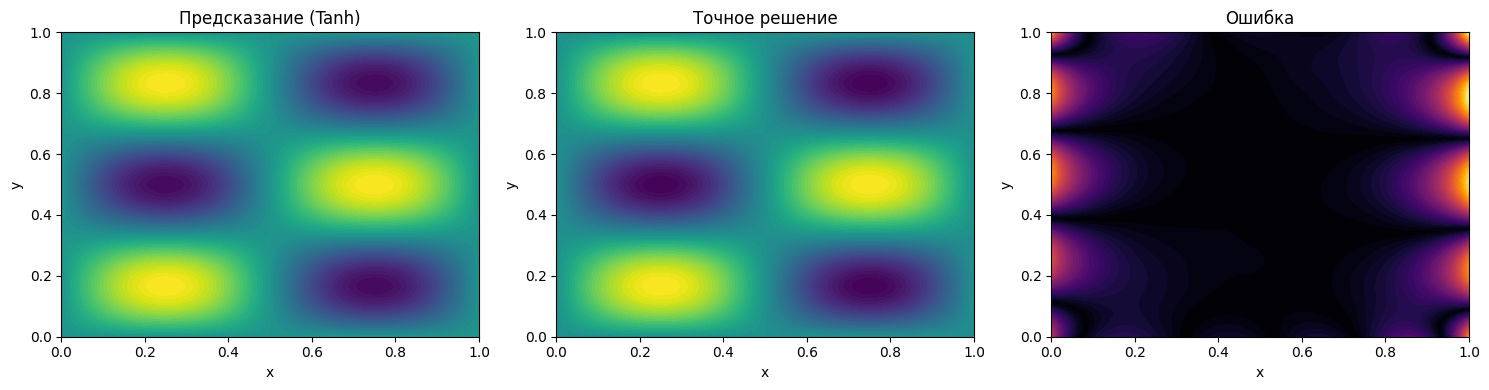

Обучаем GELU:
 1000 | Loss 1.10e+00 | PDE 5.39e-01 | BC 3.73e-02
 2000 | Loss 2.62e-01 | PDE 1.29e-01 | BC 8.77e-03
 3000 | Loss 6.32e-02 | PDE 3.38e-02 | BC 1.95e-03
 4000 | Loss 3.74e-02 | PDE 2.46e-02 | BC 8.46e-04
 5000 | Loss 4.61e+00 | PDE 4.59e+00 | BC 1.71e-03
 6000 | Loss 1.31e-02 | PDE 5.86e-03 | BC 4.80e-04
 7000 | Loss 1.57e-02 | PDE 1.05e-02 | BC 3.44e-04
 8000 | Loss 1.50e-02 | PDE 1.03e-02 | BC 3.10e-04
 9000 | Loss 9.43e-03 | PDE 5.06e-03 | BC 2.89e-04
10000 | Loss 7.23e-03 | PDE 4.44e-03 | BC 1.84e-04
11000 | Loss 1.66e+00 | PDE 1.66e+00 | BC 5.87e-04
12000 | Loss 7.20e-03 | PDE 3.01e-03 | BC 2.77e-04
13000 | Loss 5.70e-03 | PDE 3.17e-03 | BC 1.67e-04
14000 | Loss 6.18e-02 | PDE 5.96e-02 | BC 1.46e-04
15000 | Loss 4.40e-03 | PDE 2.11e-03 | BC 1.52e-04
16000 | Loss 1.94e-01 | PDE 1.80e-01 | BC 9.00e-04
17000 | Loss 3.57e-03 | PDE 2.05e-03 | BC 1.00e-04
18000 | Loss 3.26e-03 | PDE 1.90e-03 | BC 8.96e-05
19000 | Loss 1.17e-02 | PDE 1.02e-02 | BC 9.69e-05
20000 | Loss 2.51

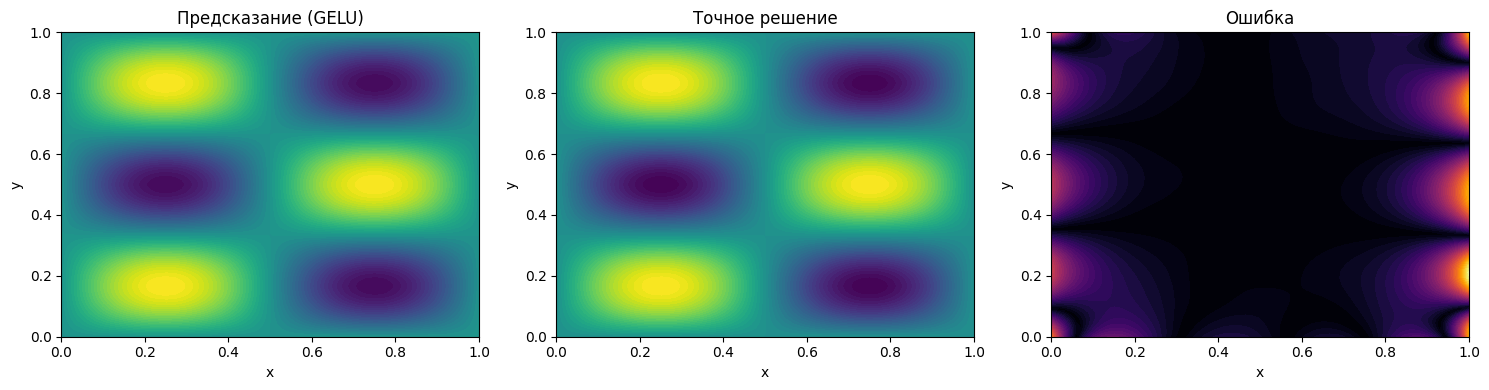

Обучаем SIREN:
 1000 | Loss 9.85e-01 | PDE 1.41e-01 | BC 2.05e-02
 2000 | Loss 4.10e-01 | PDE 6.23e-02 | BC 8.47e-03
 3000 | Loss 2.04e-01 | PDE 3.12e-02 | BC 4.20e-03
 4000 | Loss 9.00e-02 | PDE 1.95e-02 | BC 1.72e-03
 5000 | Loss 3.33e-02 | PDE 9.77e-03 | BC 5.73e-04
 6000 | Loss 2.04e-02 | PDE 1.35e-02 | BC 1.67e-04
 7000 | Loss 8.07e-03 | PDE 3.81e-03 | BC 1.04e-04
 8000 | Loss 5.33e-03 | PDE 3.05e-03 | BC 5.54e-05
 9000 | Loss 5.72e-03 | PDE 3.29e-03 | BC 5.93e-05
10000 | Loss 9.43e-03 | PDE 7.73e-03 | BC 4.13e-05
11000 | Loss 2.95e-03 | PDE 1.47e-03 | BC 3.60e-05
12000 | Loss 3.20e-03 | PDE 1.86e-03 | BC 3.25e-05
13000 | Loss 1.97e-03 | PDE 1.01e-03 | BC 2.32e-05
14000 | Loss 3.11e-03 | PDE 1.95e-03 | BC 2.82e-05
15000 | Loss 2.89e-02 | PDE 2.81e-02 | BC 1.97e-05
16000 | Loss 1.39e-03 | PDE 6.56e-04 | BC 1.78e-05
17000 | Loss 2.67e-03 | PDE 1.97e-03 | BC 1.70e-05
18000 | Loss 1.43e-03 | PDE 7.82e-04 | BC 1.58e-05
19000 | Loss 1.58e-02 | PDE 1.52e-02 | BC 1.41e-05
20000 | Loss 1.3

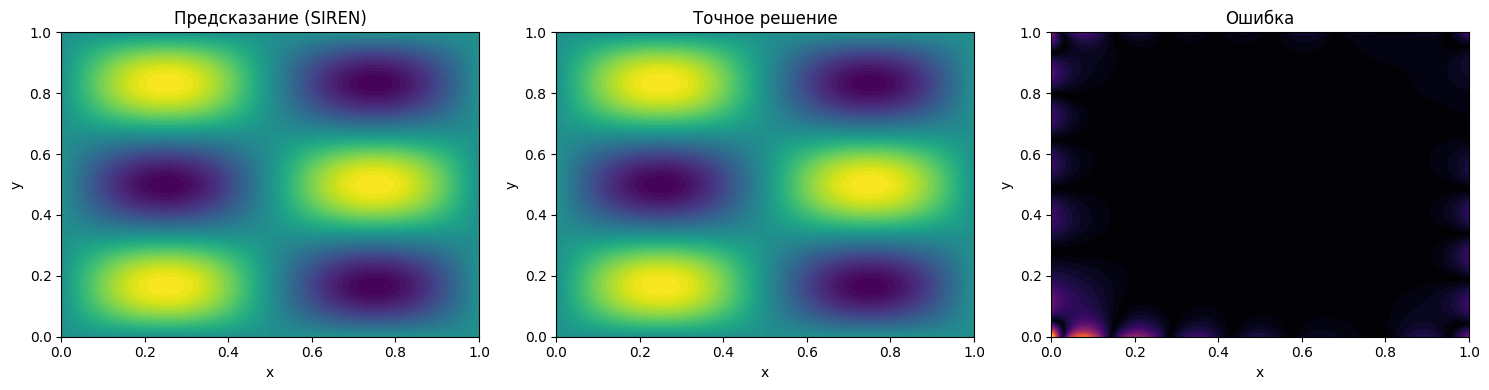


Таблица сравнения архитектур
Модель          Лучший Loss  Rel. L2    Max ошибка
--------------------------------------------------
Tanh            1.93e-03     0.0043     0.0119    
GELU            1.70e-03     0.0052     0.0161    
SIREN           1.33e-03     0.0023     0.0212    


In [7]:
best_pinn  = study_pinn.best_params
best_gelu  = study_gelu.best_params
best_siren = study_siren.best_params

layers_pinn  = [2] + [best_pinn['width']]  * best_pinn['depth']  + [1]
layers_gelu  = [2] + [best_gelu['width']]  * best_gelu['depth']  + [1]
layers_siren = [2] + [best_siren['width']] * best_siren['depth'] + [1]

configs = [
    (PINN(layers_pinn).to(device),                                  best_pinn['lr'],  best_pinn['w_b'],  'Tanh'),
    (PINNGELU(layers_gelu).to(device),                              best_gelu['lr'],  best_gelu['w_b'],  'GELU'),
    (SIREN(layers_siren, omega_0=best_siren['omega_0']).to(device), best_siren['lr'], best_siren['w_b'], 'SIREN'),
]

results = []
loss_histories = {}

N_EPOCHS = 40000
patience = 3000
min_delta = 0.001

for model, lr, w_b, name in configs:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_int, n_bnd = 1000, 400
    interior, boundary = generate_points(n_int, n_bnd)
    w_f = 1.0

    best_loss = float('inf')
    best_state = None
    history = []
    no_improve_count = 0

    print(f'Обучаем {name}:')
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        loss, loss_pde, loss_bc = compute_loss(model, interior, boundary, w_f, w_b)
        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if loss.item() < best_loss * (1 - min_delta):
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print(f"Остановка на эпохе {epoch}")
            break

        if epoch % 1000 == 0 and epoch > 0:
            interior = generate_rad_interior(model, 1000)
            print(f"{epoch:5d} | Loss {loss.item():.2e} | PDE {loss_pde.item():.2e} | BC {loss_bc.item():.2e}")

    model.load_state_dict(best_state)
    loss_histories[name] = history
    print(f"Best loss: {best_loss:.2e}\n")

    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    model.eval()
    with torch.no_grad():
        u_pred = model(grid).cpu().reshape(100, 100)
    u_exact = exact_solution(grid).cpu().reshape(100, 100)
    error = torch.abs(u_pred - u_exact)

    rel_l2 = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()
    max_err = error.max().item()
    results.append({'Model': name, 'Best Loss': f'{best_loss:.2e}', 'Rel. L2': f'{rel_l2:.4f}', 'Max Error': f'{max_err:.4f}'})

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].contourf(X, Y, u_pred, levels=50, cmap='viridis')
    axs[0].set_title(f'Предсказание ({name})')
    axs[1].contourf(X, Y, u_exact, levels=50, cmap='viridis')
    axs[1].set_title('Точное решение')
    axs[2].contourf(X, Y, error, levels=50, cmap='inferno')
    axs[2].set_title('Ошибка')
    for ax in axs:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()


# Таблица сравнения
print("\nТаблица сравнения архитектур")
print(f"{'Модель':<15} {'Лучший Loss':<12} {'Rel. L2':<10} {'Max ошибка':<10}")
print("-" * 50)
for r in results:
    print(f"{r['Model']:<15} {r['Best Loss']:<12} {r['Rel. L2']:<10} {r['Max Error']:<10}")

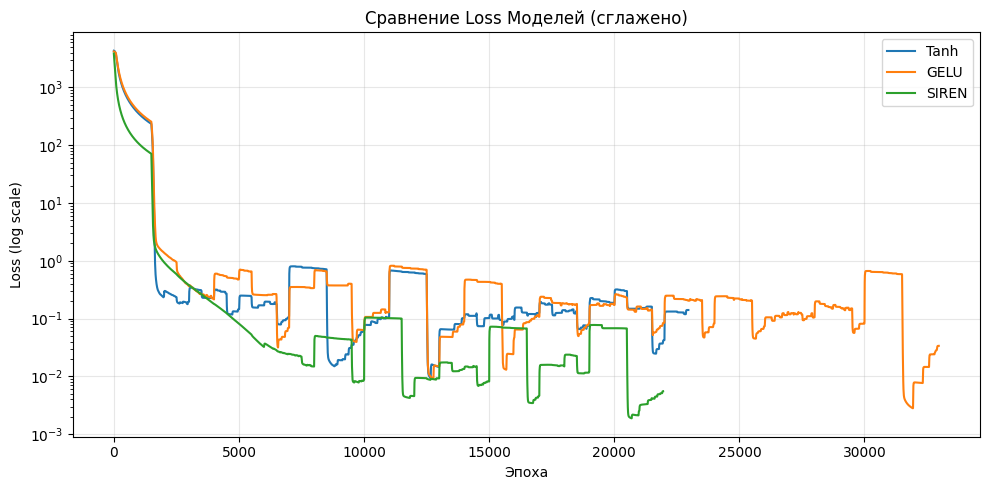

In [8]:
# График loss
fig, ax = plt.subplots(figsize=(10, 5))
window = 1500  # сглаживание
for name, history in loss_histories.items():
    smoothed = pd.Series(history).rolling(window, min_periods=1).mean()
    ax.semilogy(smoothed, label=name)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Сравнение Loss Моделей (сглажено)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Интерпретация
- От запуска к запуску результат меняется: зачастую лучше SIREN, но бывают и ситуации, в которых лучше Tanh, или даже GELU. Поэтому принято решение сделать 10 запусков с разными random seed и сравнивать результаты в среднем

####  Важные фиксации из статьи

##### Формулировка loss как задачи выполнения ограничения
Статья формализует PINN иначе, чем обычно объясняют. Задача нахождения решения уравнения Пуассона формулируется как задача выполнения
ограничений: требуется найти функцию u(x,y), одновременно удовлетворяющую дифференциальному уравнению внутри области и граничным условиям
Дирихле на её границе. Поскольку нейросеть не может выполнить эти условия точно в каждой точке, задача сводится к минимизации взвешенной
суммы штрафов за нарушение каждого ограничения. Интегралы по области и границе аппроксимируются методом Монте-Карло: на каждом шаге
обучения случайно сэмплируются точки внутри области, а периодическая перегенерация выборки уменьшает смещение оценки.

"In practice, the loss function is enforced by sampling Ω... the dataset D is sampled dynamically at training time, approximating ℒ
better as the number of samples grows, as in Monte Carlo integration."

Получается, и по заданию и по факту, я делал именно это, запуская generate_points каждые 1000 эпох. 

##### Производная SIREN — тоже SIREN 
"any derivative of a SIREN is itself a SIREN, as the derivative of the sine is a cosine, i.e., a phase-shifted sine"
Это ключевое теоретическое обоснование, почему SIREN хорош для PDE. Когда мы считаем лапласиан через aвтодифференцирование, мы получаем производную, которая сама является SIREN-образной функцией. Tanh этим свойством не обладает, его производные деградируют по качеству с каждым порядком.

##### Сравнение архитектур из статьи 
Авторы явно сравнивают ReLU, Tanh, ReLU+P.E. и SIREN на задаче Пуассона. SIREN выигрывает по качеству и скорости сходимости. 
Мой эксперимент GELU vs SIREN vs Tanh воспроизводит именно этот сравнительный анализ. 

#### 10 запусков и усреднённое сравнение


In [1]:
SEEDS = list(range(10))
N_EPOCHS_STAT = 50000
patience_stat = 3000
min_delta_stat = 0.001

def train_model(model_class, layers, lr, w_b, seed, **model_kwargs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(layers, **model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    # Фиксированный eval набор — создаётся один раз и не меняется
    eval_interior, eval_boundary = generate_points(1000, 400)

    best_loss = float('inf')
    best_state = None
    no_improve_count = 0
    stopped_at = N_EPOCHS_STAT

    for epoch in range(N_EPOCHS_STAT):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

        # Считаем eval loss отдельно — на фиксированном наборе, без grad
        with torch.no_grad():
            eval_loss, _, _ = compute_loss(model, eval_interior, eval_boundary, 1.0, w_b)
        eval_loss_val = eval_loss.item()

        # Early stopping и best_state — по eval loss
        if eval_loss_val < best_loss * (1 - min_delta_stat):
            best_loss = eval_loss_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience_stat:
            stopped_at = epoch
            break

        if epoch % 1000 == 0 and epoch > 0:
            interior = generate_rad_interior(model, 1000)

    model.load_state_dict(best_state)

    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    model.eval()
    with torch.no_grad():
        u_pred = model(grid).cpu().reshape(100, 100)
    u_exact = exact_solution(grid).cpu().reshape(100, 100)

    rel_l2 = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()
    return best_loss, rel_l2, stopped_at

stat_configs = [
    ('PINN (Tanh)', PINN,     layers_pinn,  best_pinn['lr'],  best_pinn['w_b'],  {}),
    ('PINN (GELU)', PINNGELU, layers_gelu,  best_gelu['lr'],  best_gelu['w_b'],  {}),
    ('SIREN',       SIREN,    layers_siren, best_siren['lr'], best_siren['w_b'], {'omega_0': best_siren['omega_0']}),
]

all_results = {name: {'loss': [], 'rel_l2': [], 'epochs': []} for name, *_ in stat_configs}

for name, cls, layers, lr, w_b, kwargs in stat_configs:
    print(f'{name}:')
    for seed in SEEDS:
        loss, rel_l2, epochs = train_model(cls, layers, lr, w_b, seed, **kwargs)
        all_results[name]['loss'].append(loss)
        all_results[name]['rel_l2'].append(rel_l2)
        all_results[name]['epochs'].append(epochs)
        print(f"  seed {seed:2d}: loss={loss:.2e}  rel_l2={rel_l2:.4f}  epochs={epochs}")
    print()

# Таблица
print("=== Статистика по 10 запускам ===")
print(f"{'Модель':<15} {'Loss mean':<12} {'Loss std':<12} {'Rel.L2 mean':<14} {'Rel.L2 std':<12} {'Epochs mean'}")
print("-" * 78)
for name in all_results:
    losses = all_results[name]['loss']
    rl2s   = all_results[name]['rel_l2']
    epcs   = all_results[name]['epochs']
    print(f"{name:<15} {np.mean(losses):.2e}    {np.std(losses):.2e}    {np.mean(rl2s):.4f}         {np.std(rl2s):.4f}        {int(np.mean(epcs))}")

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = list(all_results.keys())
rl2_data  = [all_results[n]['rel_l2'] for n in names]
loss_data = [all_results[n]['loss']   for n in names]

axes[0].boxplot(rl2_data, labels=names)
axes[0].set_title('Rel. L2 Error (10 seeds)')
axes[0].set_ylabel('Rel. L2')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(loss_data, labels=names)
axes[1].set_yscale('log')
axes[1].set_title('Best Loss (10 seeds, log scale)')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'PINN' is not defined

PINN (Tanh):
  seed  0: loss=1.77e-03  rel_l2=0.0041  epochs=19000
  seed  1: loss=4.78e-03  rel_l2=0.0056  epochs=11892
  seed  2: loss=2.32e-03  rel_l2=0.0047  epochs=19902
  seed  3: loss=8.48e-03  rel_l2=0.0080  epochs=14981
  seed  4: loss=1.60e-03  rel_l2=0.0036  epochs=16972
  seed  5: loss=1.60e-03  rel_l2=0.0032  epochs=15947
  seed  6: loss=2.43e-03  rel_l2=0.0043  epochs=16598
  seed  7: loss=2.44e-03  rel_l2=0.0046  epochs=23980
  seed  8: loss=2.10e-03  rel_l2=0.0042  epochs=18828
  seed  9: loss=1.59e-03  rel_l2=0.0037  epochs=24999

PINN (GELU):
  seed  0: loss=1.71e-03  rel_l2=0.0069  epochs=32999
  seed  1: loss=4.57e-03  rel_l2=0.0094  epochs=16988
  seed  2: loss=2.85e-03  rel_l2=0.0080  epochs=24968
  seed  3: loss=4.03e-03  rel_l2=0.0086  epochs=17997
  seed  4: loss=3.32e-03  rel_l2=0.0091  epochs=16599
  seed  5: loss=1.42e-03  rel_l2=0.0046  epochs=33999
  seed  6: loss=4.73e-03  rel_l2=0.0091  epochs=17907
  seed  7: loss=2.16e-03  rel_l2=0.0066  epochs=23813
 

C:\Users\olegs\AppData\Local\Temp\ipykernel_56628\3638868305.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rl2_data, labels=names)
C:\Users\olegs\AppData\Local\Temp\ipykernel_56628\3638868305.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(loss_data, labels=names)


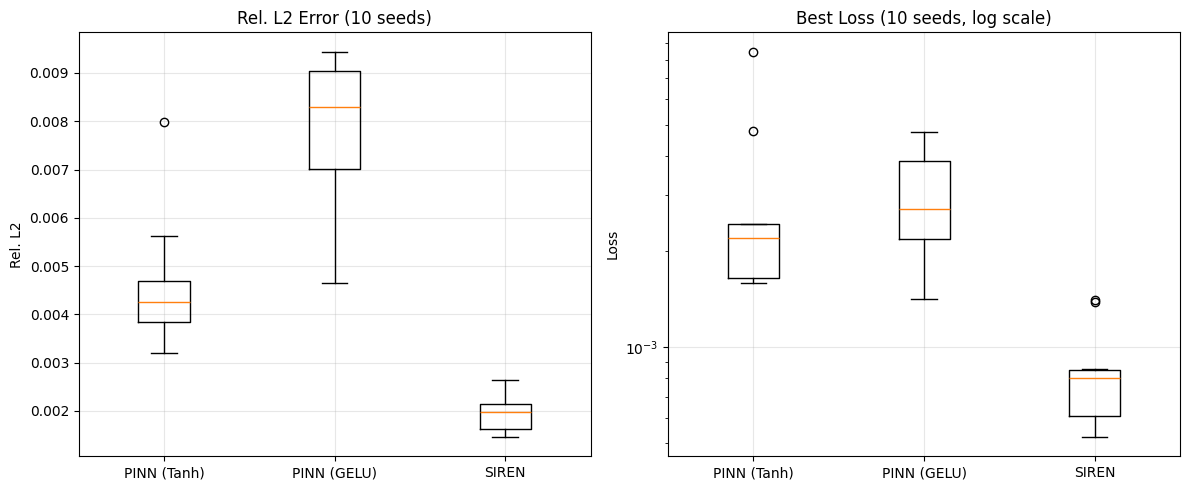

In [13]:
SEEDS = list(range(10))
N_EPOCHS_STAT = 50000
patience_stat = 3000
min_delta_stat = 0.001

def train_model(model_class, layers, lr, w_b, seed, **model_kwargs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(layers, **model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    best_loss = float('inf')
    best_state = None
    no_improve_count = 0
    stopped_at = N_EPOCHS_STAT

    for epoch in range(N_EPOCHS_STAT):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss * (1 - min_delta_stat):
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience_stat:
            stopped_at = epoch
            break

        if epoch % 1000 == 0 and epoch > 0:
            interior = generate_rad_interior(model, 1000)
            no_improve_count = 0

    model.load_state_dict(best_state)

    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    model.eval()
    with torch.no_grad():
        u_pred = model(grid).cpu().reshape(100, 100)
    u_exact = exact_solution(grid).cpu().reshape(100, 100)

    rel_l2 = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()
    return best_loss, rel_l2, stopped_at


stat_configs = [
    ('PINN (Tanh)', PINN,     layers_pinn,  best_pinn['lr'],  best_pinn['w_b'],  {}),
    ('PINN (GELU)', PINNGELU, layers_gelu,  best_gelu['lr'],  best_gelu['w_b'],  {}),
    ('SIREN',       SIREN,    layers_siren, best_siren['lr'], best_siren['w_b'], {'omega_0': best_siren['omega_0']}),
]

all_results = {name: {'loss': [], 'rel_l2': [], 'epochs': []} for name, *_ in stat_configs}

for name, cls, layers, lr, w_b, kwargs in stat_configs:
    print(f'{name}:')
    for seed in SEEDS:
        loss, rel_l2, epochs = train_model(cls, layers, lr, w_b, seed, **kwargs)
        all_results[name]['loss'].append(loss)
        all_results[name]['rel_l2'].append(rel_l2)
        all_results[name]['epochs'].append(epochs)
        print(f"  seed {seed:2d}: loss={loss:.2e}  rel_l2={rel_l2:.4f}  epochs={epochs}")
    print()

# Таблица
print("=== Статистика по 10 запускам ===")
print(f"{'Модель':<15} {'Loss mean':<12} {'Loss std':<12} {'Rel.L2 mean':<14} {'Rel.L2 std':<12} {'Epochs mean'}")
print("-" * 78)
for name in all_results:
    losses = all_results[name]['loss']
    rl2s   = all_results[name]['rel_l2']
    epcs   = all_results[name]['epochs']
    print(f"{name:<15} {np.mean(losses):.2e}    {np.std(losses):.2e}    {np.mean(rl2s):.4f}         {np.std(rl2s):.4f}        {int(np.mean(epcs))}")

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = list(all_results.keys())
rl2_data  = [all_results[n]['rel_l2'] for n in names]
loss_data = [all_results[n]['loss']   for n in names]

axes[0].boxplot(rl2_data, labels=names)
axes[0].set_title('Rel. L2 Error (10 seeds)')
axes[0].set_ylabel('Rel. L2')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(loss_data, labels=names)
axes[1].set_yscale('log')
axes[1].set_title('Best Loss (10 seeds, log scale)')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Улучшения: NTK-балансировка весов loss

##### Проблема фиксированных весов

Если градиенты от PDE loss и BC loss имеют разные масштабы, оптимизация нестабильна, компонент с большим градиентом "перетягивает" обучение. Именно это мы наблюдали: Optuna иногда находил w_b=1.5 для SIREN, и BC выполнялся плохо.

Wang et al. (2021) — "Understanding and mitigating gradient pathologies in physics-informed neural networks" — предложили адаптивную балансировку на основе Neural Tangent Kernel. Идея: пересчитывать w_b каждые K эпох так, чтобы нормы градиентов были сбалансированы:

```
λ̂ = mean(|∇_θ L_pde|) / mean(|∇_θ L_bc|)
w_b ← (1 - α) · w_b + α · λ̂
```

α — скорость адаптации (EMA). Экспоненциальное скользящее среднее сглаживает резкие изменения. Клип lambda_hat сверху нужен потому, что в начале обучения BC-градиенты близки к нулю и отношение взрывается.

##### L-BFGS

Пробовал также добавить L-BFGS финиш после Adam — квазиньютоновский метод второго порядка, который теоретически точнее попадает в минимум. На практике не дал улучшения: Adam на этой задаче уже находит достаточно хорошие минимумы, и L-BFGS к ним ничего не добавил. Убрал.

PINN (Tanh):
  seed 0: loss=7.53e-04  rel_l2=0.0008
  seed 1: loss=1.54e-03  rel_l2=0.0012
  seed 2: loss=9.04e-04  rel_l2=0.0007
  seed 3: loss=4.99e-03  rel_l2=0.0018
  seed 4: loss=1.27e-03  rel_l2=0.0010
  seed 5: loss=2.42e-03  rel_l2=0.0012
  seed 6: loss=1.42e-03  rel_l2=0.0010
  seed 7: loss=1.42e-03  rel_l2=0.0010
  seed 8: loss=1.38e-03  rel_l2=0.0009
  seed 9: loss=1.31e-03  rel_l2=0.0008

PINN (GELU):
  seed 0: loss=2.19e-03  rel_l2=0.0018
  seed 1: loss=1.28e-03  rel_l2=0.0013
  seed 2: loss=1.67e-03  rel_l2=0.0015
  seed 3: loss=2.09e-03  rel_l2=0.0015
  seed 4: loss=2.05e-03  rel_l2=0.0017
  seed 5: loss=1.46e-03  rel_l2=0.0014
  seed 6: loss=1.74e-03  rel_l2=0.0014
  seed 7: loss=1.14e-03  rel_l2=0.0013
  seed 8: loss=1.51e-03  rel_l2=0.0016
  seed 9: loss=1.69e-03  rel_l2=0.0020

SIREN:
  seed 0: loss=4.86e-04  rel_l2=0.0006
  seed 1: loss=4.02e-04  rel_l2=0.0006
  seed 2: loss=5.03e-04  rel_l2=0.0006
  seed 3: loss=1.37e-03  rel_l2=0.0010
  seed 4: loss=2.56e-04  rel_

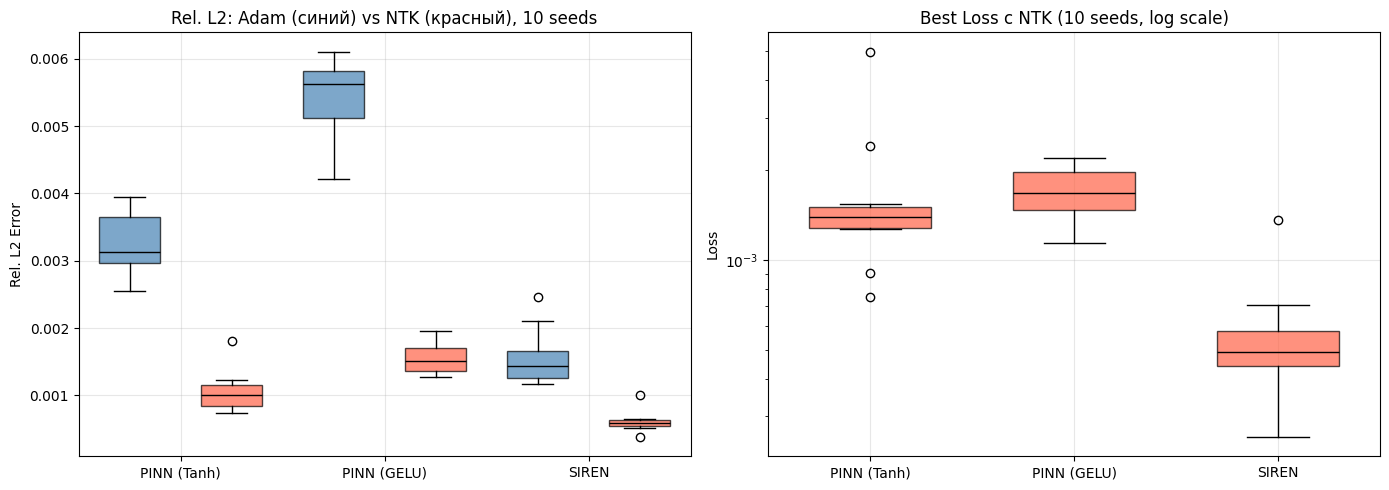

In [10]:
def train_model_ntk(model_class, layers, lr, w_b_init, seed, ntk_every=200, ntk_alpha=0.3, **model_kwargs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(layers, **model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    w_f = 1.0
    w_b = w_b_init

    best_loss = float('inf')
    best_state = None
    no_improve_count = 0
    patience = 3000
    min_delta = 0.001
    N_EPOCHS = 40000

    for epoch in range(N_EPOCHS):
        if epoch % ntk_every == 0 and epoch > 0:
            int_ntk = interior.detach().requires_grad_(True)
            _, loss_pde, loss_bc = compute_loss(model, int_ntk, boundary, 1.0, 1.0)

            grads_pde = torch.autograd.grad(loss_pde, model.parameters(),
                                            retain_graph=True, allow_unused=True)
            norm_pde = torch.sqrt(sum(g.pow(2).sum() for g in grads_pde if g is not None) + 1e-12)

            grads_bc = torch.autograd.grad(loss_bc, model.parameters(),
                                           retain_graph=False, allow_unused=True)
            norm_bc = torch.sqrt(sum(g.pow(2).sum() for g in grads_bc if g is not None) + 1e-12)

            lambda_hat = min((norm_pde / norm_bc).item(), 200.0)
            w_b = (1 - ntk_alpha) * w_b + ntk_alpha * lambda_hat

        optimizer.zero_grad()
        loss, loss_pde, loss_bc = compute_loss(model, interior, boundary, w_f, w_b)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss * (1 - min_delta):
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            break

        if epoch % 1000 == 0 and epoch > 0:
            interior, _ = generate_points(1000, 400)
            interior.requires_grad_(True)

    model.load_state_dict(best_state)

    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    model.eval()
    with torch.no_grad():
        u_pred = model(grid).cpu().reshape(100, 100)
    u_exact = exact_solution(grid).cpu().reshape(100, 100)
    rel_l2 = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()

    return best_loss, rel_l2


SEEDS_NTK = list(range(10))

ntk_configs = [
    ('PINN (Tanh)', PINN,     layers_pinn,  best_pinn['lr'],  best_pinn['w_b'],  {}),
    ('PINN (GELU)', PINNGELU, layers_gelu,  best_gelu['lr'],  best_gelu['w_b'],  {}),
    ('SIREN',       SIREN,    layers_siren, best_siren['lr'], best_siren['w_b'], {'omega_0': best_siren['omega_0']}),
]

ntk_results = {name: {'loss': [], 'rel_l2': []} for name, *_ in ntk_configs}

for name, cls, layers, lr, w_b, kwargs in ntk_configs:
    print(f'{name}:')
    for seed in SEEDS_NTK:
        loss, rel_l2 = train_model_ntk(cls, layers, lr, w_b, seed, **kwargs)
        ntk_results[name]['loss'].append(loss)
        ntk_results[name]['rel_l2'].append(rel_l2)
        print(f"  seed {seed}: loss={loss:.2e}  rel_l2={rel_l2:.4f}")
    print()

print("Сравнение: базовый Adam  vs  NTK-балансировка")
print(f"{'Модель':<15} {'Base Rel.L2':>12}  {'NTK Rel.L2':>12}  {'Улучшение':>10}")
for name, *_ in ntk_configs:
    base_mean = np.mean(all_results[name]['rel_l2'])
    ntk_mean  = np.mean(ntk_results[name]['rel_l2'])
    delta = (base_mean - ntk_mean) / base_mean * 100
    sign = "↓" if delta > 0 else "↑"
    print(f"{name:<15} {base_mean:>12.4f}  {ntk_mean:>12.4f}  {sign}{abs(delta):>8.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = [n for n, *_ in ntk_configs]

for i, name in enumerate(names):
    axes[0].boxplot(all_results[name]['rel_l2'], positions=[i*2],     widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7), medianprops=dict(color='black'))
    axes[0].boxplot(ntk_results[name]['rel_l2'], positions=[i*2 + 1], widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor='tomato',    alpha=0.7), medianprops=dict(color='black'))

axes[0].set_xticks([0.5, 2.5, 4.5])
axes[0].set_xticklabels(names)
axes[0].set_title('Rel. L2: Adam (синий) vs NTK (красный), 10 seeds')
axes[0].set_ylabel('Rel. L2 Error')
axes[0].grid(True, alpha=0.3)

for i, name in enumerate(names):
    axes[1].boxplot(ntk_results[name]['loss'], positions=[i+1], widths=0.6,
                    patch_artist=True, boxprops=dict(facecolor='tomato', alpha=0.7),
                    medianprops=dict(color='black'))
axes[1].set_yscale('log')
axes[1].set_xticks(range(1, len(names)+1))
axes[1].set_xticklabels(names)
axes[1].set_title('Best Loss с NTK (10 seeds, log scale)')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Fourier Features и feature engineering

##### Fourier Feature Network (Tancik et al., 2020)

Стандартный MLP страдает от того, что градиентный спуск сначала выучивает низкочастотные компоненты функции, а высокочастотные — медленно или никогда. Наше решение `u = sin(2πx)sin(3πy)` как раз высокочастотное.

Идея: вместо того чтобы подавать (x,y) напрямую, делаем случайную проекцию:

```
γ(x) = [sin(2π·Bᵀx), cos(2π·Bᵀx)],   B ~ N(0, σ²)
```

Матрица B фиксирована и не обучается — это гиперпараметр. Параметр σ управляет диапазоном частот.

**Результат: провал.** rel_l2 ≈ 1.0 при низком loss. Причина: уравнение Пуассона Δu=f без жёстко выполненных граничных условий имеет бесконечно много решений (любые две отличаются на гармоническую функцию). Если w_b слаб, сеть находит *другую* функцию, которая хорошо удовлетворяет PDE, но не совпадает с u_exact. С NTK (w_b→200) сеть коллапсировала в u≡0 — тоже неправильно, но по другой причине (u=0 точно удовлетворяет однородным BC). Оба подхода не сработали. Fourier исключён из финального сравнения.

##### Hard BC enforcement (feature engineering)

Вместо штрафного слагаемого `w_b · MSE(u_bc)` можно **вшить граничные условия прямо в архитектуру**. Умножаем выход сети на:

```
φ(x,y) = x·(1-x) · y·(1-y)
```

φ = 0 на всей границе [0,1]² — BC выполняется точно при любых весах. Оптимизируем только PDE residual. 

**Результат: отличный.** rel_l2 ≈ 0.0006, сравнимо с SIREN. Loss кажется высоким (1e-02) только потому что в нём нет BC-компоненты — это чистый PDE residual, несравнимый с loss других архитектур.

In [11]:
class FourierPINN(nn.Module):
    def __init__(self, layers, n_fourier=64, sigma=1.0):
        super().__init__()
        # Случайная матрица частот — фиксирована, не обучается
        B = torch.randn(2, n_fourier) * sigma
        self.register_buffer('B', B)
        self.activation = nn.Tanh()
        # Первый слой принимает 2*n_fourier (sin + cos)
        mlp_sizes = [2 * n_fourier] + layers[1:]
        self.mlp = nn.ModuleList()
        for i in range(len(mlp_sizes) - 1):
            self.mlp.append(nn.Linear(mlp_sizes[i], mlp_sizes[i + 1]))

    def forward(self, x):
        proj = 2 * np.pi * (x @ self.B)          # [N, n_fourier]
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # [N, 2*n_fourier]
        for i, layer in enumerate(self.mlp):
            x = layer(x)
            if i < len(self.mlp) - 1:
                x = self.activation(x)
        return x


class HardBCPINN(nn.Module):
    """BC вшиты в архитектуру: выход умножается на x(1-x)y(1-y) → ноль на границе."""
    def __init__(self, layers):
        super().__init__()
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i + 1]))

    def forward(self, xy):
        x_in = xy
        for i, layer in enumerate(self.layers):
            x_in = layer(x_in)
            if i < len(self.layers) - 1:
                x_in = self.activation(x_in)
        # Hard enforcement
        phi = xy[:, 0:1] * (1 - xy[:, 0:1]) * xy[:, 1:2] * (1 - xy[:, 1:2])
        return x_in * phi


def objective_fourier(trial):
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    width    = trial.suggest_categorical('width', [32, 64, 100, 128])
    depth    = trial.suggest_int('depth', 2, 5)
    w_b      = trial.suggest_float('w_b', 1.0, 50.0)
    n_fourier = trial.suggest_categorical('n_fourier', [32, 64, 128, 256])
    sigma    = trial.suggest_float('sigma', 0.5, 10.0)

    layers = [2] + [width] * depth + [1]
    model = FourierPINN(layers, n_fourier=n_fourier, sigma=sigma).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    for _ in range(3000):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

    return loss.item()


def objective_hardbc(trial):
    lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    width = trial.suggest_categorical('width', [32, 64, 100, 128])
    depth = trial.suggest_int('depth', 2, 5)
    # w_b не нужен — BC выполняется точно, но оставляем небольшой штраф как регуляризацию
    w_b   = trial.suggest_float('w_b', 0.1, 5.0)

    layers = [2] + [width] * depth + [1]
    model = HardBCPINN(layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    for _ in range(3000):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

    return loss.item()


study_fourier = optuna.create_study(direction='minimize')
study_fourier.optimize(objective_fourier, n_trials=30)
print("Fourier best:", study_fourier.best_params)

study_hardbc = optuna.create_study(direction='minimize')
study_hardbc.optimize(objective_hardbc, n_trials=30)
print("HardBC best:", study_hardbc.best_params)

Fourier best: {'lr': 0.0002301170677657552, 'width': 100, 'depth': 4, 'w_b': 1.6885352883602422, 'n_fourier': 256, 'sigma': 8.85367699423395}
HardBC best: {'lr': 0.0037300963614955176, 'width': 64, 'depth': 3, 'w_b': 1.2011850726181181}


Fourier (plain Adam):
  seed 0: loss=4.56e-04  rel_l2=0.9980
  seed 1: loss=5.49e-05  rel_l2=0.9992
  seed 2: loss=5.70e-05  rel_l2=0.9994
  seed 3: loss=1.11e-03  rel_l2=0.9984
  seed 4: loss=7.85e-05  rel_l2=0.9983
  seed 5: loss=2.65e-05  rel_l2=0.9998
  seed 6: loss=1.58e-04  rel_l2=0.9997
  seed 7: loss=5.57e-04  rel_l2=0.9996
  seed 8: loss=1.32e-03  rel_l2=0.9965
  seed 9: loss=6.41e-05  rel_l2=1.0002

HardBC (NTK):
  seed 0: loss=3.88e-03  rel_l2=0.0005
  seed 1: loss=9.24e-03  rel_l2=0.0007
  seed 2: loss=3.92e-03  rel_l2=0.0002
  seed 3: loss=1.40e-02  rel_l2=0.0005
  seed 4: loss=6.67e+01  rel_l2=1.3362
  seed 5: loss=2.92e-03  rel_l2=0.0003
  seed 6: loss=3.11e-03  rel_l2=0.0008
  seed 7: loss=4.67e-02  rel_l2=0.0005
  seed 8: loss=1.00e-02  rel_l2=0.0008
  seed 9: loss=5.37e-03  rel_l2=0.0007

Fourier rel_l2=0.9989 — архитектура провалилась: нашла другое решение PDE.
Исключаем из финального сравнения, в таблице оставляем для полноты.

=== Итоговое сравнение (10 seeds) ===


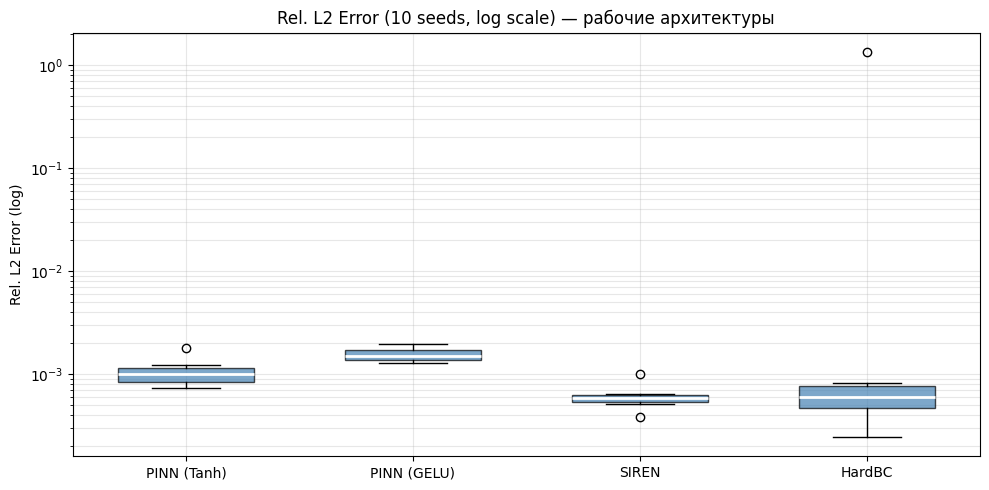

In [12]:
best_fourier = study_fourier.best_params
best_hardbc  = study_hardbc.best_params

layers_fourier = [2] + [best_fourier['width']] * best_fourier['depth'] + [1]
layers_hardbc  = [2] + [best_hardbc['width']]  * best_hardbc['depth']  + [1]


def train_model_plain(model_class, layers, lr, w_b, seed, n_epochs=40000, **model_kwargs):
    """Обычный Adam без NTK."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(layers, **model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    interior, boundary = generate_points(1000, 400)

    best_loss = float('inf')
    best_state = None
    no_improve_count = 0
    patience = 3000
    min_delta = 0.001

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, interior, boundary, 1.0, w_b)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss * (1 - min_delta):
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            break

        if epoch % 1000 == 0 and epoch > 0:
            interior, _ = generate_points(1000, 400)
            interior.requires_grad_(True)

    model.load_state_dict(best_state)

    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    model.eval()
    with torch.no_grad():
        u_pred = model(grid).cpu().reshape(100, 100)
    u_exact = exact_solution(grid).cpu().reshape(100, 100)
    rel_l2 = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()
    return best_loss, rel_l2


new_results = {'Fourier': {'loss': [], 'rel_l2': []}, 'HardBC': {'loss': [], 'rel_l2': []}}

# Fourier — plain Adam с w_b от Optuna
# Известная проблема: Δu=f без жёстких BC имеет множество решений.
# Если w_b слаб, сеть находит другую функцию с хорошим PDE residual, но u ≠ u_exact → rel_l2≈1.
print('Fourier (plain Adam):')
for seed in range(10):
    loss, rel_l2 = train_model_plain(
        FourierPINN, layers_fourier, best_fourier['lr'], best_fourier['w_b'], seed,
        n_fourier=best_fourier['n_fourier'], sigma=best_fourier['sigma']
    )
    new_results['Fourier']['loss'].append(loss)
    new_results['Fourier']['rel_l2'].append(rel_l2)
    print(f"  seed {seed}: loss={loss:.2e}  rel_l2={rel_l2:.4f}")

print('\nHardBC (NTK):')
for seed in range(10):
    loss, rel_l2 = train_model_ntk(
        HardBCPINN, layers_hardbc, best_hardbc['lr'], best_hardbc['w_b'], seed
    )
    new_results['HardBC']['loss'].append(loss)
    new_results['HardBC']['rel_l2'].append(rel_l2)
    print(f"  seed {seed}: loss={loss:.2e}  rel_l2={rel_l2:.4f}")

# Fourier провалился (rel_l2≈1) — исключаем из финального сравнения
fourier_mean = np.mean(new_results['Fourier']['rel_l2'])
print(f"\nFourier rel_l2={fourier_mean:.4f} — архитектура провалилась: нашла другое решение PDE.")
print("Исключаем из финального сравнения, в таблице оставляем для полноты.\n")

# Полная таблица (все пять)
print("=== Итоговое сравнение (10 seeds) ===")
print(f"{'Модель':<15} {'Rel.L2 mean':>12}  {'Rel.L2 std':>12}  Примечание")
print("-" * 70)
all_five = {**ntk_results, **new_results}
notes = {
    'PINN (Tanh)': '',
    'PINN (GELU)': '',
    'SIREN':       '',
    'Fourier':     '← провал: неправильное решение PDE',
    'HardBC':      '← loss несравним (нет BC-штрафа)',
}
for name in all_five:
    rl2 = all_five[name]['rel_l2']
    print(f"{name:<15} {np.mean(rl2):>12.4f}  {np.std(rl2):>12.4f}  {notes.get(name,'')}")

# Boxplot без Fourier, log scale
working = {n: all_five[n] for n in ['PINN (Tanh)', 'PINN (GELU)', 'SIREN', 'HardBC']}
fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(working):
    ax.boxplot(working[name]['rel_l2'], positions=[i+1], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='white', linewidth=2))
ax.set_yscale('log')
ax.set_xticks(range(1, len(working)+1))
ax.set_xticklabels(list(working.keys()))
ax.set_title('Rel. L2 Error (10 seeds, log scale) — рабочие архитектуры')
ax.set_ylabel('Rel. L2 Error (log)')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()